# GeoBrain Implicit Geological Modeling

Demonstrates the differentiable implicit modeling module with progressive
complexity using Universal Cokriging (Lajaunie et al. 1997).

Features demonstrated:
1. Two-layer model (single series, 1 surface)
2. Three-layer model (single series, 2 surfaces)
3. Multi-series stacking with ERODE relation
4. Fault displacement
5. End-to-end differentiability with PyTorch autograd

---

**Implicit geological modelling** (Lajaunie et al., 1997) interpolates a
continuous scalar field from **surface contact points** and **orientation
data** using Universal Co-Kriging.  Lithological units are then extracted by
thresholding the scalar field.

GeoBrain's implementation is **fully differentiable** via PyTorch autograd,
enabling gradient-based optimisation and inversion.

In [1]:
import sys
import os
sys.path.insert(0, '../..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from geobrain.geomodel.implicit import (
    ImplicitModel,
    ImplicitModelConfig,
    SeriesDefinition,
    SurfacePointData,
    OrientationData,
    FaultDefinition,
    StackRelation,
)
from geobrain.vis import plot_field, plot_comparison

DEVICE = "cpu"
NX, NZ = 80, 80
print(f"Using device: {DEVICE}")


def to_image(block_flat):
    """Reshape flat grid values to (nz, nx) image for plotting."""
    return block_flat.detach().cpu().numpy().reshape(NX, NZ).T

Using device: cpu


In [2]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

## Example 1 -- Two-Layer Model

The simplest case: a single tilted interface divides the domain into two
units.

| Input | Description |
|-------|-------------|
| `SurfacePointData` | XZ coordinates where the interface passes, labelled by `surface_id` |
| `OrientationData` | Gradient vectors indicating the "upward" direction of the scalar field |

Setting `soft=False` yields a **hard** (discrete) classification;
`soft=True` with a `temperature` parameter produces a smooth probability
field -- useful for gradient-based workflows.


Example 1: Two-Layer Model
  Scalar field shape: torch.Size([6400])
  Scalar field range: [-0.5833, 0.5833]
  Hard block unique values: [0, 1]


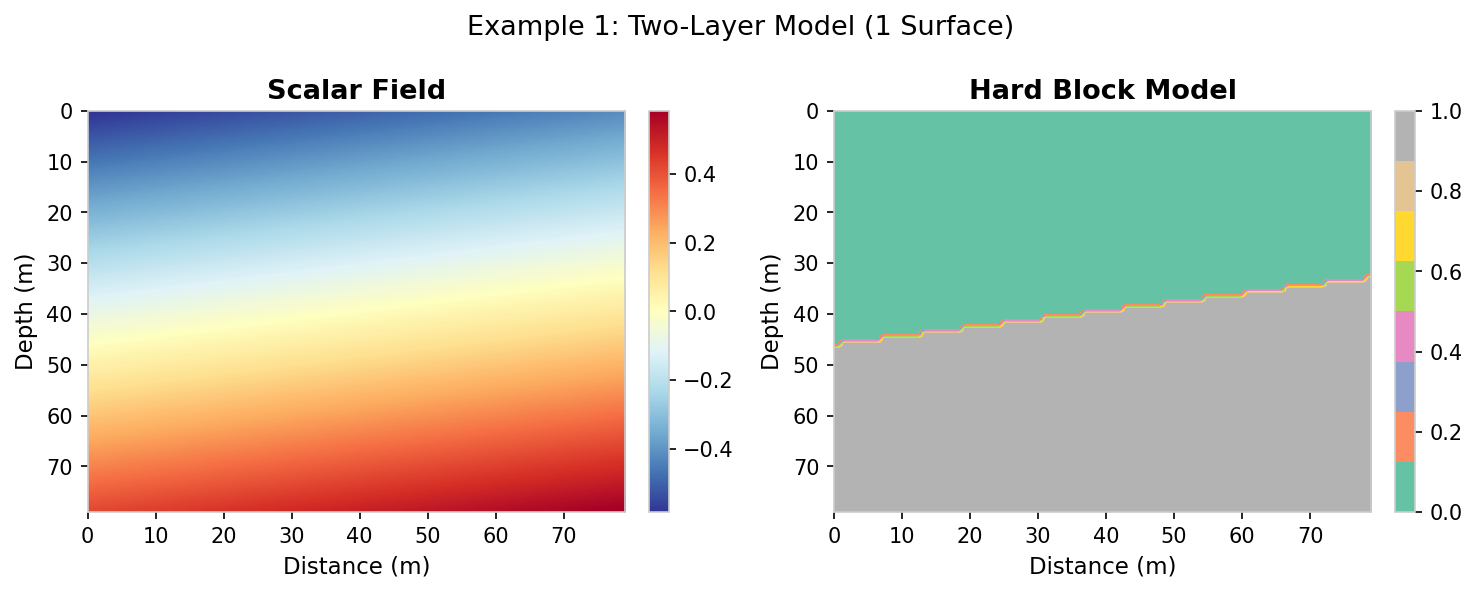

In [3]:
print("\n" + "=" * 60)
print("Example 1: Two-Layer Model")
print("=" * 60)

config1 = ImplicitModelConfig(
    extent=(0.0, 1.0, 0.0, 1.0),
    resolution=(NX, NZ),
    device=DEVICE,
    dtype="float64",
    drift_degree=1,
)

# One tilted interface: 3 surface points on surface_id=0
sp1 = SurfacePointData(
    coords=torch.tensor([
        [0.2, 0.55],
        [0.5, 0.50],
        [0.8, 0.45],
    ], dtype=torch.float64),
    surface_id=torch.tensor([0, 0, 0]),
)

# 2 orientation measurements: gradient points "up" (increasing Z)
ori1 = OrientationData(
    coords=torch.tensor([
        [0.35, 0.52],
        [0.65, 0.48],
    ], dtype=torch.float64),
    gradients=torch.tensor([
        [0.0, 1.0],
        [0.0, 1.0],
    ], dtype=torch.float64),
)

series1 = SeriesDefinition("strata", sp1, ori1)
model1 = ImplicitModel(config1, series=[series1])

# Hard block model
result1_hard = model1(soft=False)
block1_hard = result1_hard['block']
sf1 = result1_hard['scalar_fields'][0]

# Soft block model
result1_soft = model1(soft=True, temperature=50.0)
block1_soft = result1_soft['block']

print(f"  Scalar field shape: {sf1.shape}")
print(f"  Scalar field range: [{sf1.min():.4f}, {sf1.max():.4f}]")
print(f"  Hard block unique values: {torch.unique(block1_hard).tolist()}")

fig, axes = plot_comparison(
    [to_image(sf1), to_image(block1_hard)],
    titles=["Scalar Field", "Hard Block Model"],
    cmap=["RdYlBu_r", "Set2"],
    share_clim=False,
    figsize=(10, 4),
)
fig.suptitle("Example 1: Two-Layer Model (1 Surface)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_two_layer.png'))
plt.show()

## Example 2 -- Three-Layer Model

Two interfaces (`surface_id = 0, 1`) partition the domain into three units
(e.g., sandstone / shale / limestone).  Both interfaces are encoded in the
*same* scalar field and separated by two threshold values.

Compare the hard classification with the soft (probabilistic) version --
the soft output is differentiable with respect to all inputs.


Example 2: Three-Layer Model
  Scalar field range: [-0.0530, 0.0864]
  Hard block unique values: [0, 1, 2]


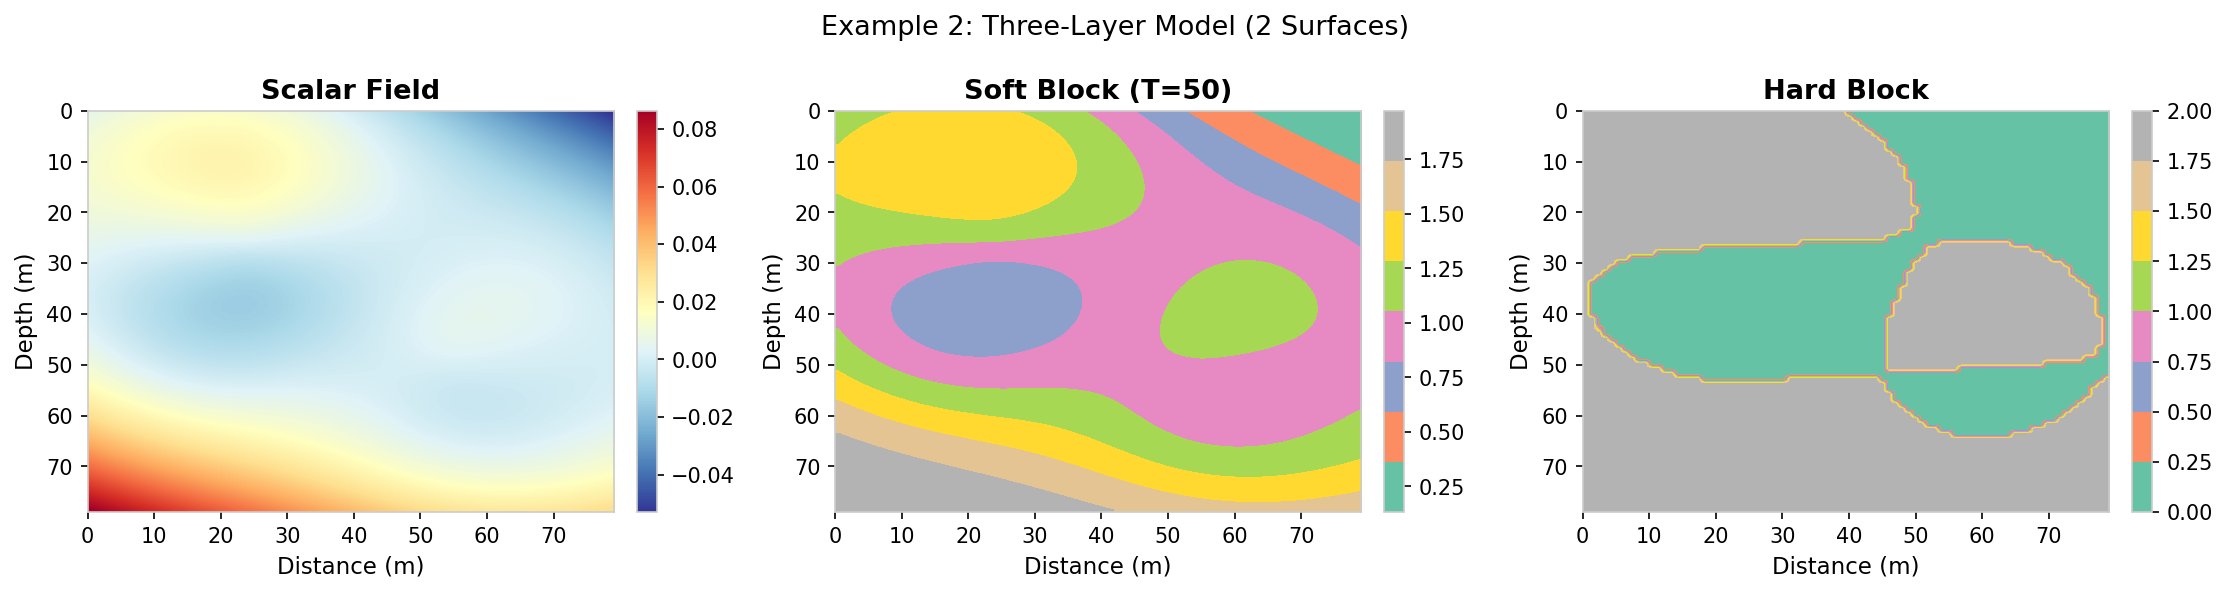

In [4]:
print("\n" + "=" * 60)
print("Example 2: Three-Layer Model")
print("=" * 60)

# Surface 0: upper interface (sandstone / shale boundary)
# Surface 1: lower interface (shale / limestone boundary)
sp2 = SurfacePointData(
    coords=torch.tensor([
        # Surface 0 — upper interface
        [0.15, 0.35], [0.40, 0.33], [0.65, 0.35], [0.90, 0.37],
        # Surface 1 — lower interface
        [0.15, 0.65], [0.40, 0.67], [0.65, 0.65], [0.90, 0.63],
    ], dtype=torch.float64),
    surface_id=torch.tensor([0, 0, 0, 0, 1, 1, 1, 1]),
)

ori2 = OrientationData(
    coords=torch.tensor([
        [0.30, 0.34],
        [0.70, 0.64],
    ], dtype=torch.float64),
    gradients=torch.tensor([
        [0.0, 1.0],
        [0.0, 1.0],
    ], dtype=torch.float64),
)

series2 = SeriesDefinition("strata", sp2, ori2)
model2 = ImplicitModel(config1, series=[series2])

result2_hard = model2(soft=False)
result2_soft = model2(soft=True, temperature=50.0)
sf2 = result2_hard['scalar_fields'][0]

print(f"  Scalar field range: [{sf2.min():.4f}, {sf2.max():.4f}]")
print(f"  Hard block unique values: {torch.unique(result2_hard['block']).tolist()}")

fig, axes = plot_comparison(
    [to_image(sf2), to_image(result2_soft['block']), to_image(result2_hard['block'])],
    titles=["Scalar Field", "Soft Block (T=50)", "Hard Block"],
    cmap=["RdYlBu_r", "Set2", "Set2"],
    share_clim=False,
    figsize=(15, 4),
)
fig.suptitle("Example 2: Three-Layer Model (2 Surfaces)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_three_layer.png'))
plt.show()

## Example 3 -- Multi-Series with ERODE Relation

Complex geology often involves **unconformities** or **intrusions** that
cut through earlier strata.  This is handled by stacking multiple *series*:

| Series | Relation | Description |
|--------|----------|-------------|
| `BASEMENT` | -- | Horizontal two-layer stratigraphy |
| `ERODE` | Cuts previous series | Dome / intrusion whose boundary overrides the basement layers |

View each series individually, then see how the combined model lets the
intrusion "erode" the basement.


Example 3: Multi-Series Stacking (ERODE)
  Basement block values:  [0, 1]
  Intrusion block values: [0, 1]
  Combined block values:  [2, 3]


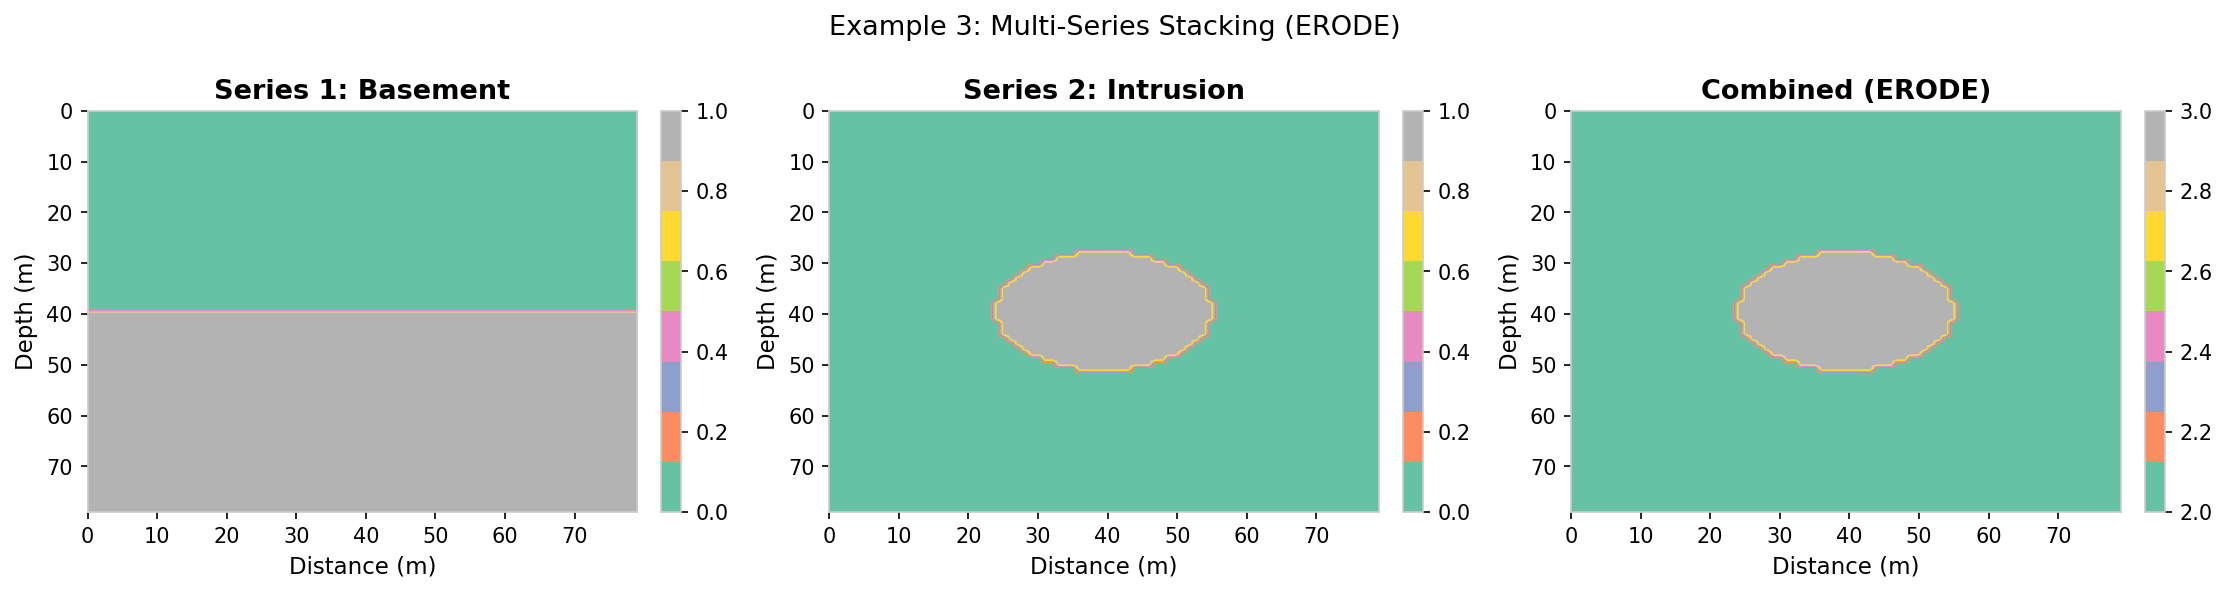

In [5]:
print("\n" + "=" * 60)
print("Example 3: Multi-Series Stacking (ERODE)")
print("=" * 60)

# Series 1 (BASEMENT): horizontal two-layer stratigraphy
sp_base = SurfacePointData(
    coords=torch.tensor([
        [0.2, 0.50], [0.5, 0.50], [0.8, 0.50],
    ], dtype=torch.float64),
    surface_id=torch.tensor([0, 0, 0]),
)
ori_base = OrientationData(
    coords=torch.tensor([[0.5, 0.50]], dtype=torch.float64),
    gradients=torch.tensor([[0.0, 1.0]], dtype=torch.float64),
)
series_base = SeriesDefinition(
    "basement", sp_base, ori_base, relation=StackRelation.BASEMENT,
)

# Series 2 (ERODE): lens / dome intrusion centred at (0.5, 0.5)
# Radial orientations pointing outward from center define a closed body
sp_lens = SurfacePointData(
    coords=torch.tensor([
        [0.50, 0.35],  # top
        [0.50, 0.65],  # bottom
        [0.30, 0.50],  # left
        [0.70, 0.50],  # right
    ], dtype=torch.float64),
    surface_id=torch.tensor([0, 0, 0, 0]),
)
ori_lens = OrientationData(
    coords=torch.tensor([
        [0.50, 0.30],
        [0.50, 0.70],
        [0.25, 0.50],
        [0.75, 0.50],
    ], dtype=torch.float64),
    gradients=torch.tensor([
        [0.0, -1.0],
        [0.0,  1.0],
        [-1.0, 0.0],
        [ 1.0, 0.0],
    ], dtype=torch.float64),
)
series_lens = SeriesDefinition(
    "intrusion", sp_lens, ori_lens, relation=StackRelation.ERODE,
)

# Run each series alone, then combined
config3 = ImplicitModelConfig(
    extent=(0.0, 1.0, 0.0, 1.0),
    resolution=(NX, NZ),
    device=DEVICE,
    dtype="float64",
    drift_degree=1,
)

model_base_only = ImplicitModel(config3, series=[series_base])
result_base = model_base_only(soft=False)

model_lens_only = ImplicitModel(config3, series=[series_lens])
result_lens = model_lens_only(soft=False)

model_combined = ImplicitModel(config3, series=[series_base, series_lens])
result_comb = model_combined(soft=False)

print(f"  Basement block values:  {torch.unique(result_base['block']).tolist()}")
print(f"  Intrusion block values: {torch.unique(result_lens['block']).tolist()}")
print(f"  Combined block values:  {torch.unique(result_comb['block']).tolist()}")

fig, axes = plot_comparison(
    [to_image(result_base['block']),
     to_image(result_lens['block']),
     to_image(result_comb['block'])],
    titles=["Series 1: Basement", "Series 2: Intrusion", "Combined (ERODE)"],
    cmap="Set2",
    share_clim=False,
    figsize=(15, 4),
)
fig.suptitle("Example 3: Multi-Series Stacking (ERODE)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_multi_series.png'))
plt.show()

## Example 4 -- Fault Displacement

A **fault** is defined by its own surface points and orientations (the fault
plane geometry), plus a `displacement` parameter that controls the throw.

Compare the unfaulted and faulted models -- the interface is offset across
the fault surface.


Example 4: Fault Displacement
  Unfaulted block values: [0, 1]
  Faulted block values:   [0, 1]


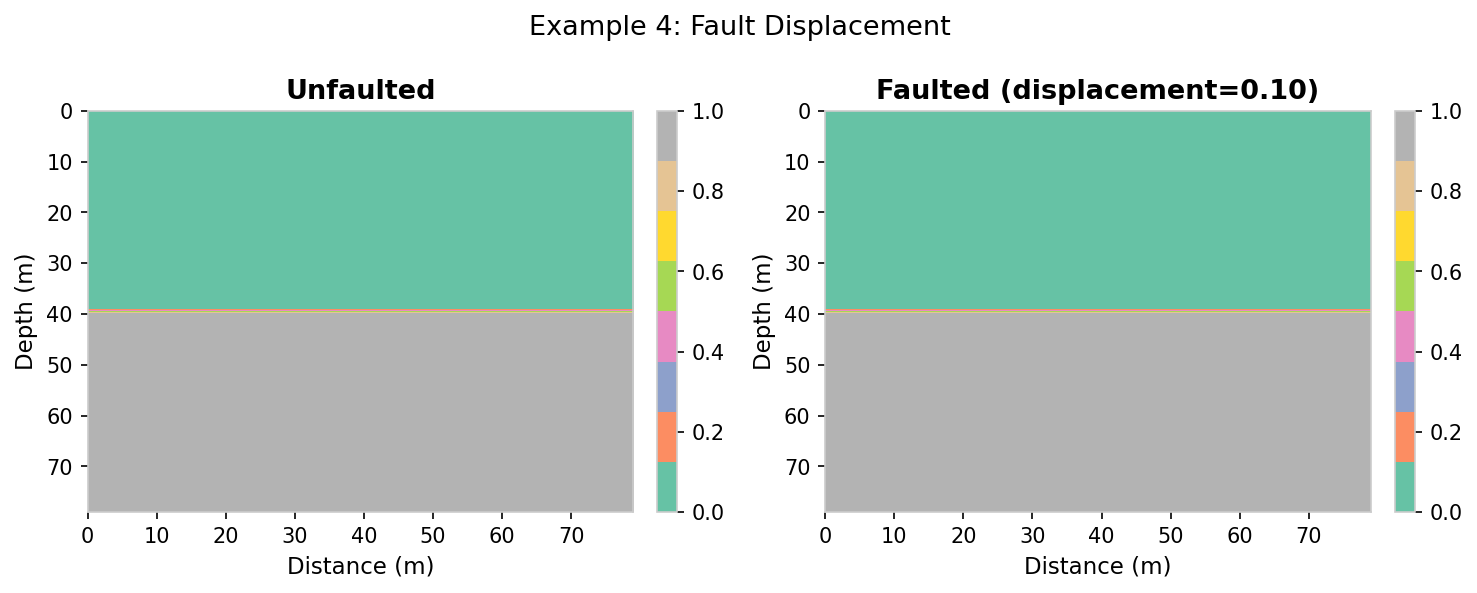

In [6]:
print("\n" + "=" * 60)
print("Example 4: Fault Displacement")
print("=" * 60)

# Stratigraphic series: horizontal two-layer
sp_strat = SurfacePointData(
    coords=torch.tensor([
        [0.2, 0.50], [0.5, 0.50], [0.8, 0.50],
    ], dtype=torch.float64),
    surface_id=torch.tensor([0, 0, 0]),
)
ori_strat = OrientationData(
    coords=torch.tensor([[0.5, 0.50]], dtype=torch.float64),
    gradients=torch.tensor([[0.0, 1.0]], dtype=torch.float64),
)
series_strat = SeriesDefinition(
    "strata", sp_strat, ori_strat, relation=StackRelation.BASEMENT,
)

# Fault: vertical plane at x=0.5
sp_fault = SurfacePointData(
    coords=torch.tensor([
        [0.50, 0.3],
        [0.50, 0.5],
        [0.50, 0.7],
    ], dtype=torch.float64),
    surface_id=torch.tensor([0, 0, 0]),
)
ori_fault = OrientationData(
    coords=torch.tensor([
        [0.50, 0.4],
        [0.50, 0.6],
    ], dtype=torch.float64),
    gradients=torch.tensor([
        [1.0, 0.0],
        [1.0, 0.0],
    ], dtype=torch.float64),
)
fault_def = FaultDefinition(
    name="normal_fault",
    surface_points=sp_fault,
    orientations=ori_fault,
    displacement=0.10,
)

config4 = ImplicitModelConfig(
    extent=(0.0, 1.0, 0.0, 1.0),
    resolution=(NX, NZ),
    device=DEVICE,
    dtype="float64",
    drift_degree=1,
)

# Unfaulted model
model_nofault = ImplicitModel(config4, series=[series_strat])
result_nofault = model_nofault(soft=False)

# Faulted model
model_fault = ImplicitModel(config4, series=[series_strat], faults=[fault_def])
result_fault = model_fault(soft=False)

print(f"  Unfaulted block values: {torch.unique(result_nofault['block']).tolist()}")
print(f"  Faulted block values:   {torch.unique(result_fault['block']).tolist()}")

fig, axes = plot_comparison(
    [to_image(result_nofault['block']), to_image(result_fault['block'])],
    titles=["Unfaulted", "Faulted (displacement=0.10)"],
    cmap="Set2",
    share_clim=False,
    figsize=(10, 4),
)
fig.suptitle("Example 4: Fault Displacement", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_fault.png'))
plt.show()

## Example 5 -- End-to-End Differentiability

This example proves that gradients flow through the entire implicit
modelling pipeline.  We:

1. Enable `requires_grad=True` on the surface-point coordinates
2. Run the forward pass (`soft=True`)
3. Compute a scalar loss and call `loss.backward()`
4. Check that `coords.grad` is non-zero

This capability is the foundation for **inversion** -- optimising geological
inputs to fit geophysical observations.


Example 5: Differentiability Demo
  Soft block range: [0.0000, 1.0000]
  Loss (mean block): 0.500000
  Gradient shape: torch.Size([3, 2])
  Gradient values:
tensor([[-0.0676, -0.4056],
        [-0.0294, -0.1763],
        [-0.0676, -0.4056]], dtype=torch.float64)
  Gradient norm: 0.608349
  --> Gradients are non-zero: end-to-end differentiability confirmed!


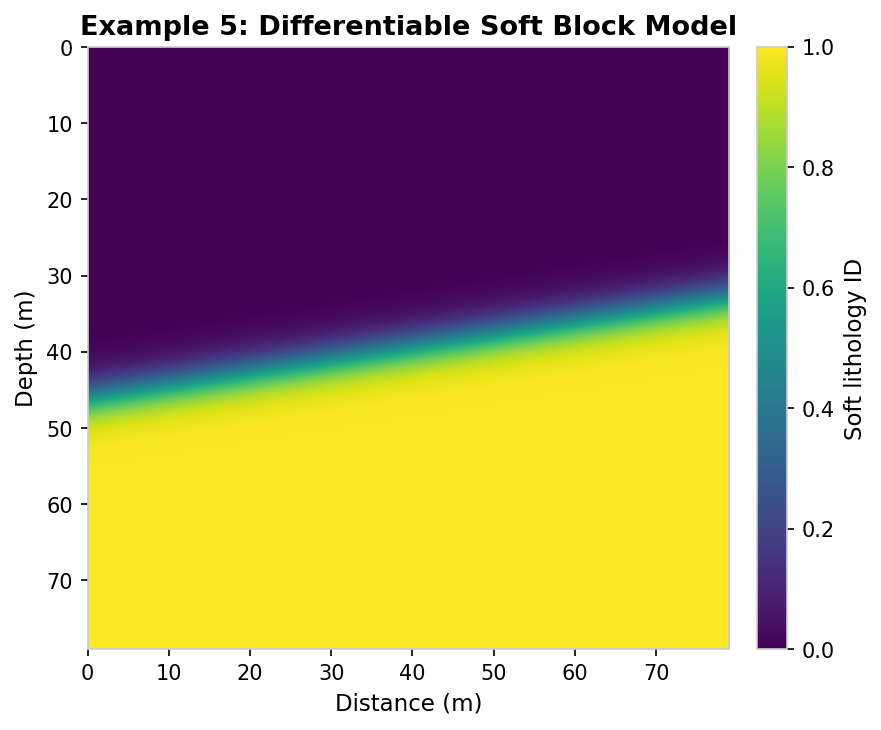


All examples completed successfully.


In [7]:
print("\n" + "=" * 60)
print("Example 5: Differentiability Demo")
print("=" * 60)

# Create surface points with gradients enabled
sp_diff = SurfacePointData(
    coords=torch.tensor([
        [0.2, 0.55],
        [0.5, 0.50],
        [0.8, 0.45],
    ], dtype=torch.float64, requires_grad=True),
    surface_id=torch.tensor([0, 0, 0]),
)
ori_diff = OrientationData(
    coords=torch.tensor([
        [0.35, 0.52],
        [0.65, 0.48],
    ], dtype=torch.float64),
    gradients=torch.tensor([
        [0.0, 1.0],
        [0.0, 1.0],
    ], dtype=torch.float64),
)

config5 = ImplicitModelConfig(
    extent=(0.0, 1.0, 0.0, 1.0),
    resolution=(NX, NZ),
    device=DEVICE,
    dtype="float64",
    drift_degree=1,
)

series_diff = SeriesDefinition("strata", sp_diff, ori_diff)
model_diff = ImplicitModel(config5, series=[series_diff])

# Forward pass with soft classification
result_diff = model_diff(soft=True, temperature=50.0)
block_soft = result_diff['block']

# Define a simple loss: mean block value (arbitrary, just to show gradients flow)
loss = block_soft.mean()

print(f"  Soft block range: [{block_soft.min():.4f}, {block_soft.max():.4f}]")
print(f"  Loss (mean block): {loss.item():.6f}")

# Backward pass
loss.backward()

grad = sp_diff.coords.grad
print(f"  Gradient shape: {grad.shape}")
print(f"  Gradient values:\n{grad}")
print(f"  Gradient norm: {grad.norm():.6f}")

if grad.norm() > 0:
    print("  --> Gradients are non-zero: end-to-end differentiability confirmed!")
else:
    print("  --> WARNING: zero gradients detected.")

# Visualize soft block model
fig, ax = plot_field(
    to_image(block_soft),
    cmap="viridis",
    label="Soft lithology ID",
    figsize=(6, 5),
)
ax.set_title("Example 5: Differentiable Soft Block Model")
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '03_differentiable.png'))
plt.show()

print("\nAll examples completed successfully.")